In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load data
data = pd.read_csv('Movie Reviews.csv')

# Convert labels: 'pos' = 1 (positive review), 'neg' = 0 (negative review)
data['label'] = data['tag'].apply(lambda x: 1 if x == 'pos' else 0)


In [2]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

# Convert texts to vector representation (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)


In [3]:
# Function for training the model and printing metrics
def train_and_evaluate(alpha):
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vectorized, y_train)
    y_pred = model.predict(X_test_vectorized)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Alpha: {alpha} - Model accuracy: {accuracy:.4f}")
    return accuracy, y_pred


In [4]:
# Tune the optimal alpha value
alphas = np.linspace(0.1, 1.0, 10)
accuracies = []
best_alpha = None
best_accuracy = 0

for alpha in alphas:
    accuracy, y_pred = train_and_evaluate(alpha)
    accuracies.append(accuracy)
    if accuracy > best_accuracy:
        best_alpha = alpha
        best_accuracy = accuracy


Alpha: 0.1 - Model accuracy: 0.7110
Alpha: 0.2 - Model accuracy: 0.7140
Alpha: 0.30000000000000004 - Model accuracy: 0.7166
Alpha: 0.4 - Model accuracy: 0.7185
Alpha: 0.5 - Model accuracy: 0.7187
Alpha: 0.6 - Model accuracy: 0.7176
Alpha: 0.7000000000000001 - Model accuracy: 0.7174
Alpha: 0.8 - Model accuracy: 0.7164
Alpha: 0.9 - Model accuracy: 0.7160
Alpha: 1.0 - Model accuracy: 0.7134


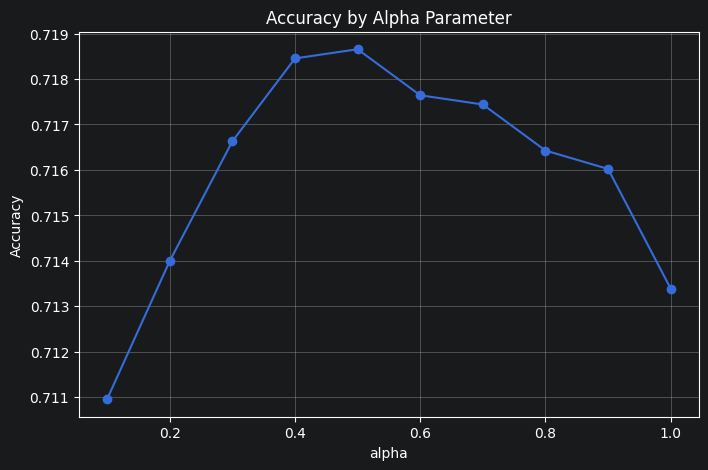

In [5]:
# Visualize accuracy by alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, accuracies, marker='o')
plt.title("Accuracy by Alpha Parameter")
plt.xlabel("alpha")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [6]:
# Train the model with the best alpha and print the classification report
print(f"\nBest alpha parameter: {best_alpha}, Accuracy: {best_accuracy:.4f}")
model = MultinomialNB(alpha=best_alpha)
model.fit(X_train_vectorized, y_train)
y_pred = model.predict(X_test_vectorized)

print("Classification report:\n", classification_report(y_test, y_pred))



Best alpha parameter: 0.5, Accuracy: 0.7187
Classification report:
               precision    recall  f1-score   support

           0       0.73      0.64      0.68      2316
           1       0.71      0.79      0.75      2621

    accuracy                           0.72      4937
   macro avg       0.72      0.71      0.71      4937
weighted avg       0.72      0.72      0.72      4937



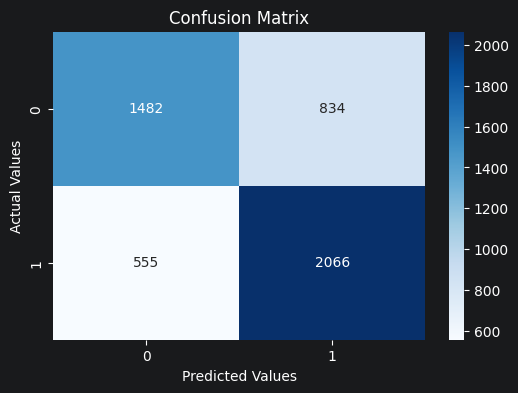

In [7]:
# Build and display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()
